# Week 7 : Mini Project 3 (Not Graded)
<hr class=red-dashed-ruler>

## Set ups 
<hr class=red-dashed-ruler>

In [2]:
!jupyter nbconvert --to notebook --execute --inplace ../utilities.ipynb

[NbConvertApp] Converting notebook ../utilities.ipynb to notebook
C:\tools\Anaconda3\Lib\site-packages\zmq\_future.py:718: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())` to avoid this warning.
  self._get_loop()
[NbConvertApp] Writing 13060 bytes to ..\utilities.ipynb


<hr class=red-dashed-ruler>

This is a practice assignment and is not graded.
It is designed to reinforce learning and enhance understanding, the Submit option and completion indicators (green tick/status) are disabled.

 
**Learning Objectives Addressed:**

Understand core probability concepts and uncertainty.

Learn the role of probability distributions in modeling real-world variability.

Explore how variability impacts business decisions such as inventory planning and risk pooling.

Interpret probabilistic patterns in datasets for predictive and prescriptive decision-making.

These practice exercises are designed for self-learning and reinforcement. They will help you strengthen your understanding of fundamental Python concepts through practical application.



<hr class=red-dashed-ruler>

**Understand the Scenario**

You will use the dataset:
File: diceroll.csv

Review the columns to understand the dice-rolling simulation data:

Roll1 → result of first die

Roll2 → result of second die

Sum → Roll1 + Roll2

You are analyzing simulated dice rolls to explore:

Empirical vs theoretical probabilities

Independence of dice

Outcome distributions

Conditional probabilities

Expected values and variance

This mini project deepens your understanding of uniform, joint, and conditional probability using simulation.



<hr class=red-dashed-ruler>

## Initial Steps

In [13]:
import pandas as pd 
import matplotlib.pyplot as plt

df=pd.read_csv("data/diceroll.csv")
print(df.head())
df.count()

   Trial  Roll1  Roll2  Sum
0      1      4      1    5
1      2      5      1    6
2      3      2      6    8
3      4      2      5    7
4      5      6      4   10


Trial    100
Roll1    100
Roll2    100
Sum      100
dtype: int64

<hr class=red-dashed-ruler>

## Mini Project 4 – Coin Toss: Questions

### Q1 : What is the empirical probability of getting a sum of 7?

#### Actual Data ( Empirical)

In [6]:
p_sum_of_7 = (df.Roll1 + df.Roll2 == 7).mean()
print("What is the empirical probability of getting a sum of 7 ?: ", p_sum_of_7)

What is the empirical probability of getting a sum of 7 ?:  0.2


<hr class=red-dashed-ruler>

### Q2 : How many trials resulted in doubles (both dice same)?

In [14]:
(df.Roll1 == df.Roll2 )

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [15]:
p_both_same = (df.Roll1 == df.Roll2 ).sum()

In [17]:
print("How many trials resulted in doubles (both dice same)?: ", p_both_same)

How many trials resulted in doubles (both dice same)?:  15


<hr class=red-dashed-ruler>

### Q3 :What is the most frequent outcome for Sum?



In [33]:
most_fequent = (df.Roll1 + df.Roll2).value_counts()
most_common, number_of_occ_of_mc = most_fequent.idxmax(), most_fequent.max()
print("What is the most frequent outcome for Sum? and number of occurence: ",most_common, "," ,number_of_occ_of_mc)

What is the most frequent outcome for Sum? and number of occurence:  7 , 20


<hr class=red-dashed-ruler>

### Q4 :Create a histogram of Sum values.


In [34]:
df["roll_sum"] = df.Roll1 + df.Roll2

In [35]:
df

,Trial,Roll1,Roll2,Sum,roll_sum
0,1,4,1,5,5
1,2,5,1,6,6
2,3,2,6,8,8
3,4,2,5,7,7
4,5,6,4,10,10
...,...,...,...,...,...
95,96,5,2,7,7
96,97,1,6,7,7
97,98,2,3,5,5
98,99,4,5,9,9


In [37]:
hist_data=df.groupby("roll_sum").size()

<Axes: ylabel='Frequency'>

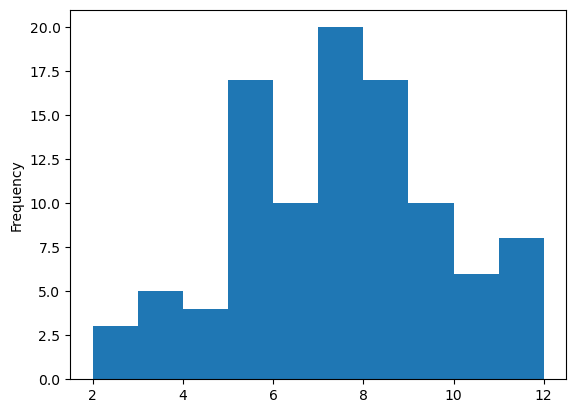

In [40]:
df.roll_sum.plot(kind="hist")

#### Better plot

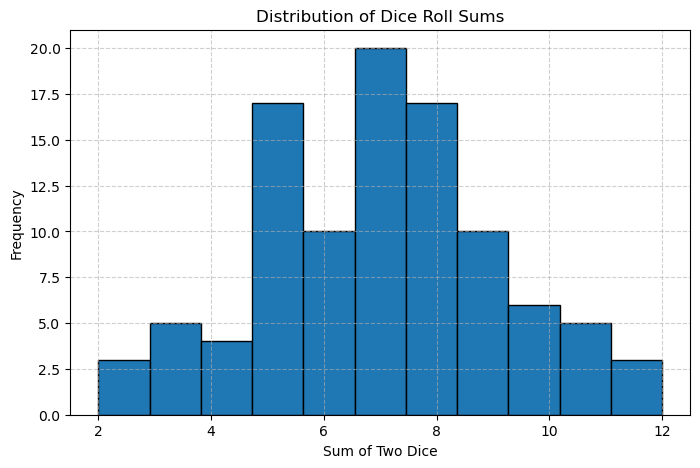

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))  # control size

plt.hist(df['roll_sum'], bins=11, edgecolor='black')

plt.title("Distribution of Dice Roll Sums")
plt.xlabel("Sum of Two Dice")
plt.ylabel("Frequency")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

<hr class=red-dashed-ruler>

### Q5 : What is the probability of getting an even sum?

In [51]:
even = lambda x: x%2==0
grouped_rs = df.groupby(['roll_sum'])['roll_sum']
p_even_sum = grouped_rs.apply(even,include_groups=False).mean()
print("What is the probability of getting an even sum? : ", p_even_sum)

What is the probability of getting an even sum? :  0.43


<hr class=red-dashed-ruler>

### Q6 : Calculate the mean and standard deviation of the Sum.

In [52]:
rs_mean = df["roll_sum"].mean()

In [53]:
rs_sd = df["roll_sum"].std()

In [55]:
print("mean of the Sum ? : ", rs_mean)
print("standard deviation of the Sum ? : ", rs_sd)

mean of the Sum ? :  6.99
standard deviation of the Sum ? :  2.324637475809807


<hr class=red-dashed-ruler>

### Q7 : Are Roll1 and Roll2 independent? Provide justification.

Two variables are independent if:
P(Roll1=a and Roll2=b)=P(Roll1=a)×P(Roll2=b)

In [57]:
# Joint probability P(Roll1=1 and Roll2=1)
joint = len(df[(df['Roll1'] == 1) & (df['Roll2'] == 1)]) / len(df)

# Marginal probabilities
p_r1 = len(df[df['Roll1'] == 1]) / len(df)
p_r2 = len(df[df['Roll2'] == 1]) / len(df)

print("Joint:", joint)
print("Product:", p_r1 * p_r2)


Joint: 0.03
Product: 0.026600000000000002


They are approximately equal. This means they are indeppendent. 

<hr class=red-dashed-ruler>

### Q8 : What is the theoretical probability of getting a sum of 12?

Out of 36 possible combinations, only 1 results in a sum of 12. Hence the theoretical probability of sum of 12 is : 1/36 =0.03

<hr class=red-dashed-ruler>

### Q9 : Compare empirical vs theoretical probability for a sum of 2.

#### Theoretical Probability

Out of 36 possible combinations, only 1 results in a sum of 2. Hence the theoretical probability of sum of 2 is : 1/36 =0.0278

#### Empirical Probability (From Your Dataset)

In [69]:
p_empirical = (df['roll_sum'] == 2).mean()
print(p_empirical)

0.03


#### Comparison

You should observe something like:

Theoretical → 0.28
Empirical → ≈ 0.28 to 0.32 (depends on sample size)

<hr class=red-dashed-ruler>

### Q10 : What is the conditional probability of Roll2 = 6 given Roll1 = 6?

In [70]:
p_six_given_six= (df[df["Roll1"]==6]["Roll2"] == 6).mean()
print("What is the conditional probability of Roll2 = 6 given Roll1 = 6? : ", p_six_given_six)

What is the conditional probability of Roll2 = 6 given Roll1 = 6? :  0.1875


<hr class=red-dashed-ruler>

### Q11 : Find the proportion of outcomes with Sum > 8.

In [78]:
df

,Trial,Roll1,Roll2,Sum,roll_sum
0,1,4,1,5,5
1,2,5,1,6,6
2,3,2,6,8,8
3,4,2,5,7,7
4,5,6,4,10,10
...,...,...,...,...,...
95,96,5,2,7,7
96,97,1,6,7,7
97,98,2,3,5,5
98,99,4,5,9,9


In [79]:
p_rs_gt_eight= (df["roll_sum"]>8).mean()

In [81]:
print("Find the proportion of outcomes with Sum > 8. : ", p_rs_gt_eight)


Find the proportion of outcomes with Sum > 8. :  0.24


<hr class=red-dashed-ruler>

### Q12 : Estimate the expected value of Sum from the data.

In [84]:
ex_rollsum = df["roll_sum"].mean()

In [85]:
print("Estimate the expected value of Sum from the data : ", ex_rollsum)

Estimate the expected value of Sum from the data :  6.99


<hr class=red-dashed-ruler>

### Q13 : Use the dataset to estimate P(odd Roll1 and even Roll2).

In [99]:
p_odd_even_roll= ((df["Roll1"]%2 == 1) & (df["Roll2"]%2 == 0)).mean()
print("Use the dataset to estimate P(odd Roll1 and even Roll2) : ", p_odd_even_roll)


Use the dataset to estimate P(odd Roll1 and even Roll2) :  0.24


<hr class=red-dashed-ruler>

### Q14: Build a joint frequency table of Roll1 and Roll2.

In [104]:
counts = df.groupby(["Roll1", "Roll2"]).size()
probs = counts / counts.sum()

In [105]:
probs

Roll1  Roll2
1      1        0.03
       2        0.03
       3        0.02
       4        0.01
       5        0.03
       6        0.02
2      1        0.02
       2        0.01
       3        0.03
       4        0.01
       5        0.04
       6        0.05
3      1        0.01
       2        0.03
       3        0.03
       4        0.05
       5        0.03
       6        0.04
4      1        0.10
       2        0.01
       3        0.05
       4        0.02
       5        0.02
5      1        0.02
       2        0.03
       3        0.04
       4        0.02
       5        0.03
       6        0.01
6      1        0.01
       2        0.03
       3        0.02
       4        0.03
       5        0.04
       6        0.03
dtype: float64

In [106]:
#### Another way

In [108]:
joint_table = pd.crosstab(df["Roll1"], df["Roll2"],normalize=True)
print(joint_table)

Roll2     1     2     3     4     5     6
Roll1                                    
1      0.03  0.03  0.02  0.01  0.03  0.02
2      0.02  0.01  0.03  0.01  0.04  0.05
3      0.01  0.03  0.03  0.05  0.03  0.04
4      0.10  0.01  0.05  0.02  0.02  0.00
5      0.02  0.03  0.04  0.02  0.03  0.01
6      0.01  0.03  0.02  0.03  0.04  0.03


In [109]:
joint_table = pd.crosstab(df["Roll1"], df["Roll2"])
print(joint_table)

Roll2   1  2  3  4  5  6
Roll1                   
1       3  3  2  1  3  2
2       2  1  3  1  4  5
3       1  3  3  5  3  4
4      10  1  5  2  2  0
5       2  3  4  2  3  1
6       1  3  2  3  4  3


<hr class=red-dashed-ruler>

### Q15: Reflect on whether the rolls follow a uniform distribution.

In [110]:
roll1_dist = df['Roll1'].value_counts(normalize=True).sort_index()
roll2_dist = df['Roll2'].value_counts(normalize=True).sort_index()

print("Roll1 distribution:\n", roll1_dist)
print("\nRoll2 distribution:\n", roll2_dist)

Roll1 distribution:
 Roll1
1    0.14
2    0.16
3    0.19
4    0.20
5    0.15
6    0.16
Name: proportion, dtype: float64

Roll2 distribution:
 Roll2
1    0.19
2    0.14
3    0.19
4    0.14
5    0.19
6    0.15
Name: proportion, dtype: float64


#### Reflection (interpretation)

If your dataset is large:

    * Each value (1–6) should appear roughly equally
    * Small deviations are normal due to randomness
    
If your dataset is small:

    * You may see noticeable imbalance
    * That does not mean bias, just sampling variability

Values we have hear is some what equal but not perfectly

<hr class=red-dashed-ruler>